# Revenue Forecast — Linear Regression

Forecasts monthly revenue using a simple linear regression model with time and seasonality features.

**Dataset:** [Online Retail II](https://www.kaggle.com/datasets/mashlyn/online-retail-ii-uci) — place the file at `data/online_retail_II.xlsx`

## 1. Load & Prepare Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression

df = pd.read_excel("data/online_retail_II.xlsx")
df['Revenue'] = df['Price'] * df['Quantity']
df['Month'] = df['InvoiceDate'].dt.to_period('M')

In [2]:
# Aggregate to monthly level
monthly_revenue = df.groupby('Month').agg({
    'Invoice': 'nunique',
    'Quantity': 'sum',
    'Revenue': 'sum',
    'Customer ID': 'nunique'
}).reset_index()

# Drop the last (incomplete) month
monthly_revenue = monthly_revenue[:-1]
print(monthly_revenue.shape)
monthly_revenue

(12, 5)


,Month,Invoice,Quantity,Revenue,Customer ID
0,2009-12,2330,420088,799847.110,1045
1,2010-01,1633,375363,624032.892,786
2,2010-02,1969,368402,533091.426,807
3,2010-03,2367,489370,765848.761,1111
4,2010-04,1892,351971,590580.432,998
5,2010-05,2418,364095,615322.830,1062
6,2010-06,2216,388253,679786.610,1095
7,2010-07,2017,302201,575236.360,988
8,2010-08,1877,451803,656776.340,964
9,2010-09,2375,478262,853650.431,1202


## 2. Visualise Monthly Revenue

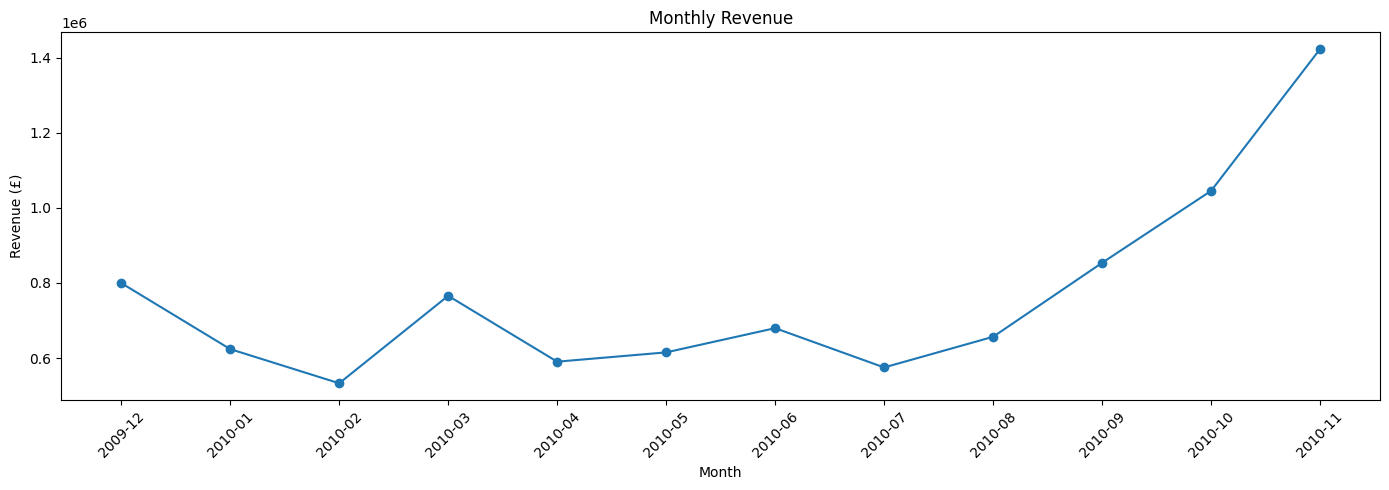

In [3]:
plt.figure(figsize=(14, 5))
plt.plot(monthly_revenue['Month'].astype(str), monthly_revenue['Revenue'], marker='o')
plt.title('Monthly Revenue')
plt.xlabel('Month')
plt.ylabel('Revenue (£)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 3. Feature Engineering

In [4]:
# Time index (linear trend feature)
monthly_revenue['Time'] = range(len(monthly_revenue))

# Month number captures seasonality
monthly_revenue['Month_num'] = monthly_revenue['Month'].dt.month

X = monthly_revenue[['Time', 'Month_num']]
y = monthly_revenue['Revenue']

## 4. Train / Test Split

In [5]:
# Hold out last 2 months as test set
X_train, X_test = X[:-2], X[-2:]
y_train, y_test = y[:-2], y[-2:]

print(f"Train size: {X_train.shape[0]} months")
print(f"Test  size: {X_test.shape[0]} months")

Train size: 10 months
Test  size: 2 months


## 5. Train Model & Evaluate

In [6]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(f"MAE:  £{mean_absolute_error(y_test, y_pred):,.0f}")
print(f"RMSE: £{mean_squared_error(y_test, y_pred)**0.5:,.0f}")
print(f"R²:   {r2_score(y_test, y_pred):.3f}")

print("\nActual:   ", y_test.values)
print("Predicted:", y_pred)

MAE:  £487,548
RMSE: £519,864
R²:   -6.586

Actual:    [1045168.35  1422654.642]
Predicted: [738050.64305556 754675.74762222]


## 6. Plot Actual vs Predicted

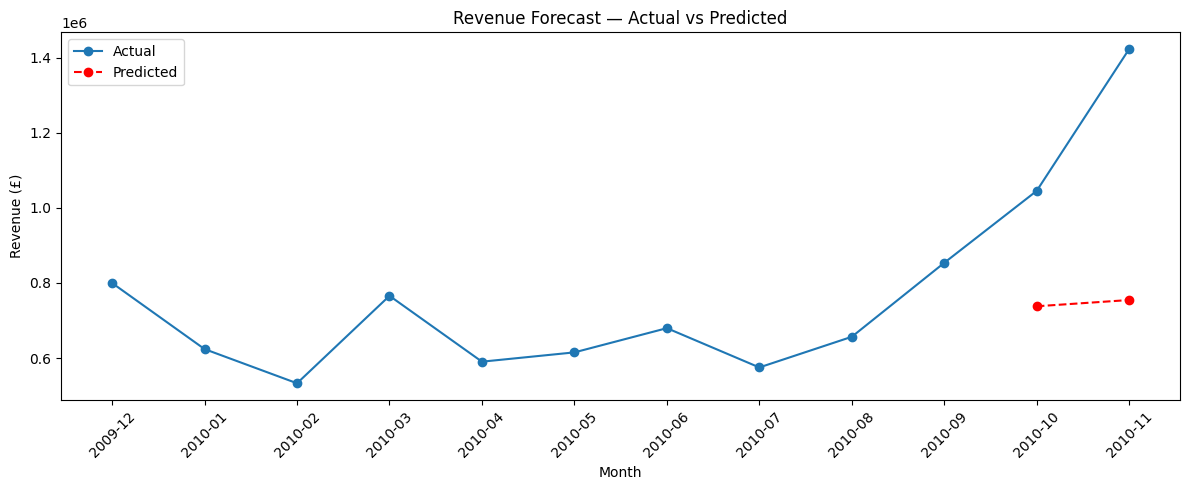

In [7]:
plt.figure(figsize=(12, 5))
plt.plot(monthly_revenue['Month'].astype(str),
         monthly_revenue['Revenue'],
         marker='o', label='Actual')
plt.plot(monthly_revenue['Month'].astype(str)[-2:],
         y_pred,
         marker='o', linestyle='--', color='red', label='Predicted')
plt.title('Revenue Forecast — Actual vs Predicted')
plt.xlabel('Month')
plt.ylabel('Revenue (£)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()